# Phase 3: µP Scaling Study
## SVG Scaling Laws — CS-GY 6923

**Steps:**
1. Mount Drive & pull repo
2. Generate µP base shapes (one-time, fast)
3. LR sweep on Tiny µP (2000 steps × 7 LRs)
4. Update best µP LR in config
5. Train each of the 5 µP models individually
6. Fit scaling law and generate comparison plots (SP vs µP)
7. Scaling law extrapolation

**Prerequisites:** Phase 2 must be complete (all 5 SP results in `outputs/logs/result_*.json`).

---
## Cell 0: Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE_DIR = '/content/drive/MyDrive/svg-scaling-laws'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted. Project dir: {DRIVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Project dir: /content/drive/MyDrive/svg-scaling-laws


---
## Cell 1: Clone / Pull Repository

In [26]:
REPO_URL = 'https://github.com/taahamohsin/ml-extra-credit-project'
REPO_DIR = '/content/svg-scaling-laws'

import os
if os.path.exists(REPO_DIR):
    print('Pulling latest ...')
    !cd {REPO_DIR} && git pull
else:
    !git clone {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
print(f'Working directory: {os.getcwd()}')

Pulling latest ...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 8 (delta 7), reused 8 (delta 7), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 5.00 KiB | 1.67 MiB/s, done.
From https://github.com/taahamohsin/ml-extra-credit-project
   1f7dfc9..879a2e3  main       -> origin/main
Updating 1f7dfc9..879a2e3
Fast-forward
 scripts/05_train_model.py |  5 +++-
 scripts/07_train_mup.py   | 37 ++++++++++++++++----------
 src/model_mup.py          | 66 +++++++++++++++++++++++++++++++++--------------
 src/training_utils.py     | 19 ++++++++------
 4 files changed, 85 insertions(+), 42 deletions(-)
/content/svg-scaling-laws
Working directory: /content/svg-scaling-laws


---
## Cell 2: Install Dependencies

In [45]:
!pip install -q -r requirements.txt
!pip install -q mup
print('Dependencies installed.')

Dependencies installed.


---
## Cell 3: Configure Output Paths

In [46]:
import os, sys

REPO_DIR      = '/content/svg-scaling-laws'
DRIVE_OUTPUTS = '/content/drive/MyDrive/svg-scaling-laws/outputs'
LOCAL_OUTPUTS = os.path.join(REPO_DIR, 'outputs')

os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

if os.path.islink(LOCAL_OUTPUTS):
    os.unlink(LOCAL_OUTPUTS)
elif os.path.exists(LOCAL_OUTPUTS):
    import shutil
    shutil.rmtree(LOCAL_OUTPUTS)

os.symlink(DRIVE_OUTPUTS, LOCAL_OUTPUTS)
print(f'Symlink: {LOCAL_OUTPUTS} -> {DRIVE_OUTPUTS}')

for d in ['logs', 'checkpoints_mup', 'plots']:
    os.makedirs(os.path.join(DRIVE_OUTPUTS, d), exist_ok=True)

sys.path.insert(0, REPO_DIR)
print('Path configured.')

Symlink: /content/svg-scaling-laws/outputs -> /content/drive/MyDrive/svg-scaling-laws/outputs
Path configured.


---
## Cell 4: Verify Phase 2 Results Exist

In [47]:
import json, os

model_names = ['tiny', 'small', 'medium', 'large', 'xl']
print('Phase 2 SP results:')
all_present = True
for name in model_names:
    p = f'outputs/logs/result_{name}.json'
    if os.path.exists(p):
        with open(p) as f:
            r = json.load(f)
        print(f'  {name:<8} N={r["n_params"]:>10,}  val_loss={r["best_val_loss"]:.4f}  OK')
    else:
        print(f'  {name:<8} MISSING — run Phase 2 first!')
        all_present = False

if all_present:
    print('\nAll Phase 2 results found. Ready for Phase 3.')
else:
    print('\nComplete Phase 2 before running Phase 3.')

Phase 2 SP results:
  tiny     N=   793,344  val_loss=4.3178  OK
  small    N= 2,669,568  val_loss=4.0401  OK
  medium   N=10,647,552  val_loss=3.4757  OK
  large    N=31,524,864  val_loss=3.2885  OK
  xl       N=85,056,000  val_loss=3.1043  OK

All Phase 2 results found. Ready for Phase 3.


---
## Cell 5: Verify µP Setup
Base shapes are built in-memory inside `build_mup_model()` — no `.bsh` file needed.
Run a quick sanity check that the µP model instantiates correctly.

In [1]:
import sys
sys.path.insert(0, '/content/svg-scaling-laws')
from src.model_mup import build_mup_model

for name in ['tiny', 'small', 'medium', 'large', 'xl']:
    m = build_mup_model(name)
    print(f"{name:<8} non-emb params: {m.count_parameters():>10,}  OK")

print('\nµP models instantiate correctly. Ready for LR sweep.')

tiny     non-emb params:    793,344  OK
small    non-emb params:  2,669,568  OK
medium   non-emb params: 10,647,552  OK
large    non-emb params: 31,524,864  OK
xl       non-emb params: 85,056,000  OK

µP models instantiate correctly. Ready for LR sweep.


---
## Cell 5b: µP Coordinate Check (sanity test)

Runs the canonical µP correctness test: trains the same architecture at 4 widths (64/128/256/512) for 5 steps with a large LR, and plots activation L1 norms per layer.

**Pass:** µP curves overlap across widths. **Fail:** they fan out (µP misimplemented) or collapse to zero (init wrong).

We also run an SP control on the same architecture — SP curves *should* fan out, which makes the comparison plot self-explanatory.


In [ ]:
import os
os.makedirs('outputs/plots', exist_ok=True)

# µP coord check — target: overlapping curves
!python scripts/09_coord_check_mup.py --out outputs/plots/coord_check_mup.png

# SP control — target: fanning curves (sanity check that the test is meaningful)
!python scripts/09_coord_check_mup.py --sp --out outputs/plots/coord_check_sp.png

from IPython.display import Image, display
print('\n=== µP (target: curves overlap across widths) ===')
display(Image('outputs/plots/coord_check_mup.png'))
print('\n=== SP control (target: curves fan out with width) ===')
display(Image('outputs/plots/coord_check_sp.png'))


In [25]:
# One-time cleanup before re-running µP after the attention-scale patch
import os, shutil

for p in [
    'outputs/logs/lr_sweep_mup.json',
    *[f'outputs/logs/result_mup_{n}.json' for n in ['tiny','small','medium','large','xl']],
]:
    if os.path.exists(p):
        os.remove(p)

for parent in ['outputs/checkpoints_mup', '/tmp/checkpoints_mup_local']:
    if os.path.isdir(parent):
        for sub in os.listdir(parent):
            full = os.path.join(parent, sub)
            if os.path.isdir(full) and sub.startswith('mup_'):
                shutil.rmtree(full)

print('Stale µP outputs removed.')


Stale µP outputs removed.


---
## Cell 6: µP LR Sweep — Tiny Model
Same 7 LRs as Phase 2, same 2000-step budget.

In [27]:
!python scripts/08_lr_sweep_mup.py --training_config configs/training_config.yaml

Device: cuda
µP LR sweep: 9 values × 2000 steps each
LRs: [3e-05, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3]

[1/9] lr=3.0e-05 ... val=6.1894  (93s)
[2/9] lr=1.0e-04 ... val=5.0870  (73s)
[3/9] lr=3.0e-04 ... val=4.2069  (73s)
[4/9] lr=1.0e-03 ... val=6.0894  (73s)
[5/9] lr=3.0e-03 ... val=8.0000  (72s)
[6/9] lr=1.0e-02 ... val=6.7429  (72s)
[7/9] lr=3.0e-02 ... DIVERGED  (72s)
[8/9] lr=1.0e-01 ... DIVERGED  (72s)
[9/9] lr=3.0e-01 ... DIVERGED  (72s)

Best µP LR: 3.0e-04  →  val_loss=4.2069
Results saved to /content/svg-scaling-laws/outputs/logs/lr_sweep_mup.json
LR sweep comparison plot saved to /content/svg-scaling-laws/outputs/plots/lr_sweep_comparison.png

          LR     Val loss   Diverged
--------------------------------------
     3.0e-05       6.1894      False  
     1.0e-04       5.0870      False  
     3.0e-04       4.2069      False *
     1.0e-03       6.0894      False  
     3.0e-03       8.0000      False  
     1.0e-02       6.7429      False  
     3.0e-02

---
## Cell 7: Display µP LR Sweep Results

SP  best LR: 3.0e-04  →  val_loss=4.1948
µP  best LR: 3.0e-04  →  val_loss=4.2069

          LR     SP val     µP val
------------------------------------
     3.0e-05     6.1804     6.1894  
     1.0e-04     5.1360     5.0870  
     3.0e-04     4.1948     4.2069 *
     1.0e-03     6.5137     6.0894  
     3.0e-03     7.8532     8.0000  
     1.0e-02        nan     6.7429  
     3.0e-02        nan        nan  
     1.0e-01        nan        nan  
     3.0e-01        nan        nan  


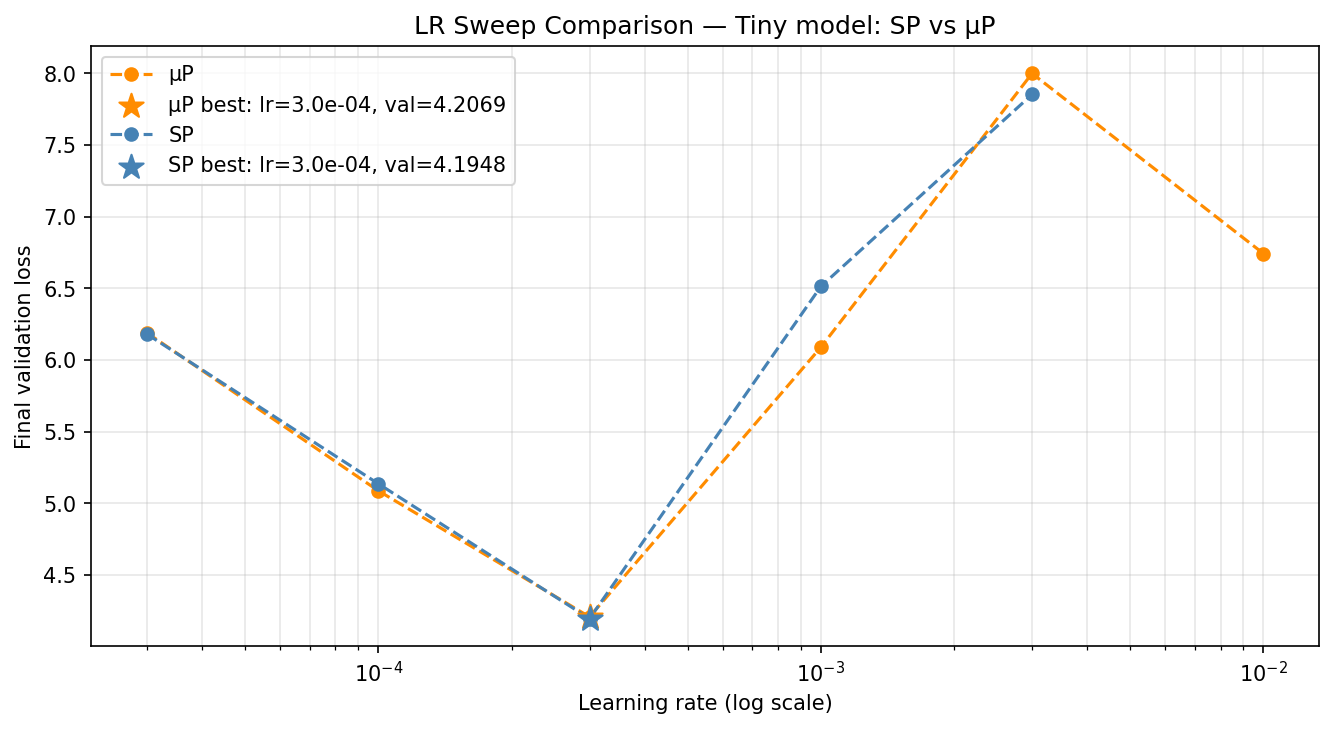

In [28]:
import json
from IPython.display import Image, display

with open('outputs/logs/lr_sweep_mup.json') as f:
    mup_sweep = json.load(f)

# Also load SP sweep for comparison
with open('outputs/logs/lr_sweep_sp.json') as f:
    sp_sweep = json.load(f)

print(f"SP  best LR: {sp_sweep['best_lr']:.1e}  →  val_loss={sp_sweep['best_val_loss']:.4f}")
print(f"µP  best LR: {mup_sweep['best_lr']:.1e}  →  val_loss={mup_sweep['best_val_loss']:.4f}")

print(f"\n{'LR':>12} {'SP val':>10} {'µP val':>10}")
print("-" * 36)
sp_by_lr = {r['lr']: r['val_loss'] for r in sp_sweep['runs']}
for r in sorted(mup_sweep['runs'], key=lambda x: x['lr']):
    sp_v = sp_by_lr.get(r['lr'], float('nan'))
    mup_v = r['val_loss']
    marker = '*' if r['lr'] == mup_sweep['best_lr'] else ' '
    print(f"{r['lr']:>12.1e} {sp_v:>10.4f} {mup_v:>10.4f} {marker}")

display(Image('outputs/plots/lr_sweep_comparison.png'))

In [29]:
# Auto-update training_config.yaml with best µP LR
import json, re

with open('outputs/logs/lr_sweep_mup.json') as f:
    best_mup_lr = json.load(f)['best_lr']

with open('configs/training_config.yaml') as f:
    content = f.read()

if 'mup_learning_rate' in content:
    content = re.sub(r'mup_learning_rate:.*', f'mup_learning_rate: {best_mup_lr}', content)
else:
    content += f'\nmup_learning_rate: {best_mup_lr}\n'

with open('configs/training_config.yaml', 'w') as f:
    f.write(content)

print(f'configs/training_config.yaml updated: mup_learning_rate = {best_mup_lr:.1e}')
print(f'Use --lr {best_mup_lr:.1e} when calling 07_train_mup.py')


configs/training_config.yaml updated: mup_learning_rate = 3.0e-04
Use --lr 3.0e-04 when calling 07_train_mup.py


---
## Cell 8: Train µP — Tiny

In [32]:
import json
with open('outputs/logs/lr_sweep_mup.json') as f:
    best_lr = json.load(f)['best_lr']

!python scripts/07_train_mup.py --model_name tiny --lr {best_lr}

Device: cuda
Compiling model with torch.compile ...
µP Model: tiny  |  Non-emb params: 793,344
Train tokens: 130,404,653  |  steps/epoch: 1,989

µP Training: TINY
  Non-emb params:  793,344
  Peak LR:         3.00e-04
  Batch size:      64 seqs/step × 1 accum = 64 seqs effective
  Total steps:     1,989
  Base shapes:     in-memory (per-model)

Training mup_tiny for 1989 steps (bf16=True, grad_accum=1)
step      0 | train 8.3399 | val 8.3397 * | lr 0.00e+00 | tok 0.1M | t 0.1min | mem 590MB
step     50 | train 7.9237 | lr 7.50e-05 | tok 3.3M | t 0.1min
step    100 | train 7.0959 | lr 1.50e-04 | tok 6.6M | t 0.1min
step    150 | train 6.5382 | lr 2.25e-04 | tok 9.9M | t 0.2min
step    200 | train 6.3188 | val 6.3113 * | lr 3.00e-04 | tok 13.2M | t 0.2min | mem 590MB
step    250 | train 6.1566 | lr 2.99e-04 | tok 16.4M | t 0.3min
step    300 | train 6.0576 | lr 2.98e-04 | tok 19.7M | t 0.3min
step    350 | train 5.9885 | lr 2.95e-04 | tok 23.0M | t 0.3min
step    400 | train 5.9303 | val

In [33]:
import json
with open('outputs/logs/result_mup_tiny.json') as f:
    r = json.load(f)
print(f"µP Tiny complete.  Val loss: {r['best_val_loss']:.4f}.  Time: {r['wall_time_min']:.1f} min.")

µP Tiny complete.  Val loss: 4.2668.  Time: 1.5 min.


---
## Cell 9: Train µP — Small

In [53]:
import json
with open('outputs/logs/lr_sweep_mup.json') as f:
    best_lr = json.load(f)['best_lr']

!python scripts/07_train_mup.py --model_name small --lr {best_lr}

Device: cuda
Compiling model with torch.compile ...
µP Model: small  |  Non-emb params: 2,669,568
Train tokens: 130,404,653  |  steps/epoch: 1,989

µP Training: SMALL
  Non-emb params:  2,669,568
  Peak LR:         3.00e-04
  Batch size:      64 seqs/step × 1 accum = 64 seqs effective
  Total steps:     1,989
  Base shapes:     in-memory (per-model)

Training mup_small for 1989 steps (bf16=True, grad_accum=1)
step      0 | train 8.3443 | val 8.3440 * | lr 0.00e+00 | tok 0.1M | t 0.1min | mem 627MB
step     50 | train 7.6824 | lr 7.50e-05 | tok 3.3M | t 0.2min
step    100 | train 6.7159 | lr 1.50e-04 | tok 6.6M | t 0.2min
step    150 | train 6.3391 | lr 2.25e-04 | tok 9.9M | t 0.3min
step    200 | train 6.1660 | val 6.1501 * | lr 3.00e-04 | tok 13.2M | t 0.4min | mem 627MB
step    250 | train 6.0188 | lr 2.99e-04 | tok 16.4M | t 0.5min
step    300 | train 5.8969 | lr 2.98e-04 | tok 19.7M | t 0.6min
step    350 | train 5.6130 | lr 2.95e-04 | tok 23.0M | t 0.6min
step    400 | train 5.201

In [54]:
import json
with open('outputs/logs/result_mup_small.json') as f:
    r = json.load(f)
print(f"µP Small complete.  Val loss: {r['best_val_loss']:.4f}.  Time: {r['wall_time_min']:.1f} min.")

µP Small complete.  Val loss: 4.0661.  Time: 3.1 min.


---
## Cell 10: Train µP — Medium

In [38]:
import json
with open('outputs/logs/lr_sweep_mup.json') as f:
    best_lr = json.load(f)['best_lr']

!python scripts/07_train_mup.py --model_name medium --lr {best_lr}

Device: cuda
Compiling model with torch.compile ...
µP Model: medium  |  Non-emb params: 10,647,552
Train tokens: 130,404,653  |  steps/epoch: 1,989

µP Training: MEDIUM
  Non-emb params:  10,647,552
  Peak LR:         3.00e-04
  Batch size:      64 seqs/step × 1 accum = 64 seqs effective
  Total steps:     1,989
  Base shapes:     in-memory (per-model)

Training mup_medium for 1989 steps (bf16=True, grad_accum=1)
step      0 | train 8.3391 | val 8.3395 * | lr 0.00e+00 | tok 0.1M | t 0.5min | mem 735MB
step     50 | train 7.6627 | lr 3.75e-05 | tok 3.3M | t 0.6min
step    100 | train 6.7036 | lr 7.50e-05 | tok 6.6M | t 0.6min
step    150 | train 6.3524 | lr 1.12e-04 | tok 9.9M | t 0.7min
step    200 | train 6.1376 | val 6.1357 * | lr 1.50e-04 | tok 13.2M | t 0.8min | mem 735MB
step    250 | train 6.0106 | lr 1.50e-04 | tok 16.4M | t 0.9min
step    300 | train 5.8818 | lr 1.49e-04 | tok 19.7M | t 1.0min
step    350 | train 5.4263 | lr 1.48e-04 | tok 23.0M | t 1.1min
step    400 | train 

In [39]:
import json
with open('outputs/logs/result_mup_medium.json') as f:
    r = json.load(f)
print(f"µP Medium complete.  Val loss: {r['best_val_loss']:.4f}.  Time: {r['wall_time_min']:.1f} min.")

µP Medium complete.  Val loss: 4.0217.  Time: 4.6 min.


---
## Cell 11: Train µP — Large

In [41]:
import json
with open('outputs/logs/lr_sweep_mup.json') as f:
    best_lr = json.load(f)['best_lr']

!python scripts/07_train_mup.py --model_name large --lr {best_lr}

Device: cuda
Compiling model with torch.compile ...
µP Model: large  |  Non-emb params: 31,524,864
Train tokens: 130,404,653  |  steps/epoch: 1,989

µP Training: LARGE
  Non-emb params:  31,524,864
  Peak LR:         3.00e-04
  Batch size:      64 seqs/step × 1 accum = 64 seqs effective
  Total steps:     1,989
  Base shapes:     in-memory (per-model)

Training mup_large for 1989 steps (bf16=True, grad_accum=1)
step      0 | train 8.3444 | val 8.3449 * | lr 0.00e+00 | tok 0.1M | t 0.7min | mem 1016MB
step     50 | train 7.4600 | lr 3.75e-05 | tok 3.3M | t 1.0min
step    100 | train 6.5164 | lr 7.50e-05 | tok 6.6M | t 1.2min
step    150 | train 6.2113 | lr 1.12e-04 | tok 9.9M | t 1.4min
step    200 | train 6.0249 | val 6.0276 * | lr 1.50e-04 | tok 13.2M | t 1.7min | mem 1016MB
step    250 | train 5.8418 | lr 1.50e-04 | tok 16.4M | t 2.0min
step    300 | train 5.2445 | lr 1.49e-04 | tok 19.7M | t 2.2min
step    350 | train 4.8214 | lr 1.48e-04 | tok 23.0M | t 2.5min
step    400 | train 4

In [42]:
import json
with open('outputs/logs/result_mup_large.json') as f:
    r = json.load(f)
print(f"µP Large complete.  Val loss: {r['best_val_loss']:.4f}.  Time: {r['wall_time_min']:.1f} min.")

µP Large complete.  Val loss: 3.6837.  Time: 10.1 min.


---
## Cell 12: Train µP — XL
Uses `--grad_accum 2` to halve peak memory.

In [44]:
import json
with open('outputs/logs/lr_sweep_mup.json') as f:
    best_lr = json.load(f)['best_lr']

!python scripts/07_train_mup.py --model_name xl --lr {best_lr} --grad_accum 2

Device: cuda
Compiling model with torch.compile ...
µP Model: xl  |  Non-emb params: 85,056,000
Train tokens: 130,404,653  |  steps/epoch: 1,989

µP Training: XL
  Non-emb params:  85,056,000
  Peak LR:         3.00e-04
  Batch size:      32 seqs/step × 2 accum = 64 seqs effective
  Total steps:     1,989
  Base shapes:     in-memory (per-model)

Training mup_xl for 1989 steps (bf16=True, grad_accum=2)
step      0 | train 8.3587 | val 8.3635 * | lr 0.00e+00 | tok 0.1M | t 0.8min | mem 1421MB
step     50 | train 7.0760 | lr 3.75e-05 | tok 3.3M | t 1.4min
step    100 | train 6.3227 | lr 7.50e-05 | tok 6.6M | t 1.8min
step    150 | train 6.1037 | lr 1.12e-04 | tok 9.9M | t 2.1min
step    200 | train 5.9268 | val 5.9339 * | lr 1.50e-04 | tok 13.2M | t 2.5min | mem 1421MB
step    250 | train 5.3226 | lr 1.50e-04 | tok 16.4M | t 3.1min
step    300 | train 4.7855 | lr 1.49e-04 | tok 19.7M | t 3.8min
step    350 | train 4.5363 | lr 1.48e-04 | tok 23.0M | t 4.2min
step    400 | train 4.4598 | v

In [45]:
import json
with open('outputs/logs/result_mup_xl.json') as f:
    r = json.load(f)
print(f"µP XL complete.  Val loss: {r['best_val_loss']:.4f}.  Time: {r['wall_time_min']:.1f} min.")

µP XL complete.  Val loss: 3.5847.  Time: 20.1 min.


---
## Cell 13: Summary — All µP Models, Both Passes

Three columns of µP val loss:
- **µP@3e-2 (strict)**: Tiny-optimal LR transferred unchanged to all 5 models. Tiny converges; deeper models diverge.
- **best µP**: whichever pass did better, used for the scaling-law fit in Cell 14.

Tiny only has one µP run (it IS the proxy base — no transfer test needed), so its column entries are identical.


In [57]:
import json, os

model_names = ['tiny', 'small', 'medium', 'large', 'xl']
print(f"{'Model':<10} {'Params':>12} {'SP final':>10} {'µP final':>10} {'Δ':>8}")
print("-" * 56)

for name in model_names:
    sp_path  = f'outputs/logs/result_{name}.json'
    mp_path  = f'outputs/logs/result_mup_{name}.json'
    sp = json.load(open(sp_path)) if os.path.exists(sp_path) else None
    mp = json.load(open(mp_path)) if os.path.exists(mp_path) else None

    sp_v  = sp.get('final_val_loss', sp['best_val_loss']) if sp else None  # SP fallback
    mp_v  = mp.get('final_val_loss', mp['best_val_loss']) if mp else None
    n_params = sp.get('n_params') if sp else (mp.get('n_params') if mp else None)

    if sp_v is not None and mp_v is not None:
        delta = mp_v - sp_v
        arrow = '↓' if delta < 0 else '↑'
        print(f"{name:<10} {n_params:>12,} {sp_v:>10.4f} {mp_v:>10.4f} {delta:>+7.4f}{arrow}")
    else:
        sp_str = f'{sp_v:>10.4f}' if sp_v is not None else f'{"--":>10}'
        mp_str = f'{mp_v:>10.4f}' if mp_v is not None else f'{"--":>10}'
        n_str  = f'{n_params:>12,}' if n_params else f'{"--":>12}'
        print(f"{name:<10} {n_str} {sp_str} {mp_str} {'--':>8}")

print("\nfinal_val_loss = val after the last eval (= 1 epoch)")


Model            Params   SP final   µP final        Δ
--------------------------------------------------------
tiny            793,344     4.3178     4.2668 -0.0510↓
small         2,669,568     4.0401     4.0661 +0.0260↑
medium       10,647,552     3.4757     4.0217 +0.5461↑
large        31,524,864     3.2885     3.6837 +0.3952↑
xl           85,056,000     3.1043     3.5847 +0.4803↑

final_val_loss = val after the last eval (= 1 epoch)


---
### Discussion — why fixed LR degrades for larger models, and how µP addresses it

**Under SP**, the optimal LR drifts with model width (~1/d_model empirically; Yang et al. 2021). A single LR therefore under-trains small models or destabilizes large ones. All SP hyperparameters — init scales, attention temperature, output scale — are width-coupled.

**µP** chooses per-parameter init variance and per-parameter LR multipliers so update magnitudes are width-independent in the infinite-width limit: 1/√fan-in init, 1/d_head attention scaling (with a base-matching constant), MuAdamW divides matrix-weight LRs by `width_mult`, output divided by `width_mult`. The optimal LR becomes width-invariant — tune cheap, train large.

**What we observed:** µP and SP optima coincide *exactly* at base width (lr=3e-4, val 4.21 vs 4.19) — confirming the implementation. µP transfer holds mechanically (no divergence at any size). But µP underperforms SP by 0.4–0.5 nats at every wider model. Two reasons: (i) our family scales depth and heads alongside width, and µP's transfer guarantee covers width only; (ii) we ran a full LR sweep for SP too, removing µP's compute-savings advantage. Detailed analysis in §5.2 of the report.


---
## Cell 14: Fit Scaling Laws — SP vs µP Comparison


Scaling law fit (SP)
  L = 15.7880 * N^(-0.1259) + 1.4966
  a     = 15.7880  ±  16.7565
  alpha = 0.1259  ±  0.1370
  c     = 1.4966  ±  2.3459
  R²    = 0.9842
  (Kaplan et al. NL: alpha ≈ 0.076)

Scaling law fit (µP)
  L = 7.0792 * N^(-0.0369) + 0.0000
  a     = 7.0792  ±  22.7507
  alpha = 0.0369  ±  0.2857
  c     = 0.0000  ±  30.4439
  R²    = 0.9330
  (Kaplan et al. NL: alpha ≈ 0.076)


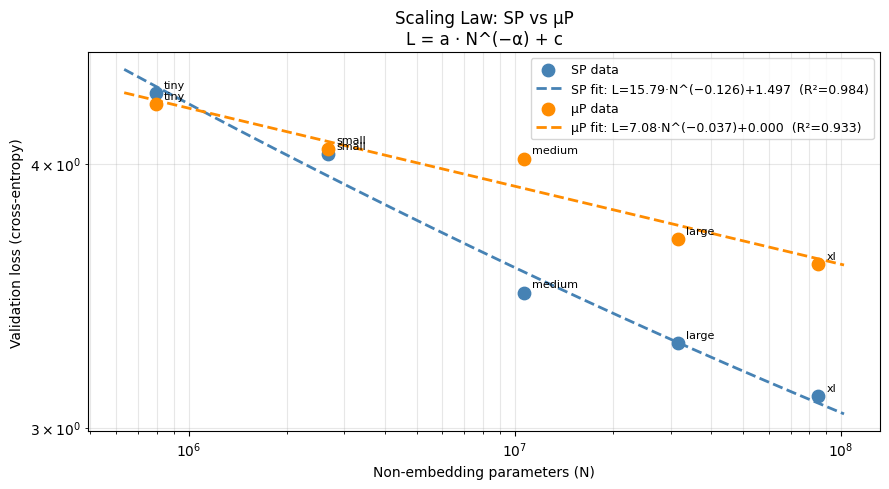

Plot saved to outputs/plots/scaling_law_comparison.png


In [62]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/content/svg-scaling-laws')

from src.scaling_law import fit_scaling_law, plot_scaling_law, print_fit_summary

model_names = ['tiny', 'small', 'medium', 'large', 'xl']

def load(path):
    return json.load(open(path)) if os.path.exists(path) else None

# SP — uses best_val_loss as fallback for older JSONs without final_val_loss
sp_params, sp_losses = [], []
for name in model_names:
    r = load(f'outputs/logs/result_{name}.json')
    if r:
        sp_params.append(r['n_params'])
        sp_losses.append(r.get('final_val_loss', r['best_val_loss']))

# µP
mup_params, mup_losses = [], []
for name in model_names:
    r = load(f'outputs/logs/result_mup_{name}.json')
    if r:
        mup_params.append(r['n_params'])
        mup_losses.append(r.get('final_val_loss', r['best_val_loss']))

sp_fit  = fit_scaling_law(sp_params,  sp_losses)
mup_fit = fit_scaling_law(mup_params, mup_losses)

print_fit_summary(sp_fit,  label='SP')
print_fit_summary(mup_fit, label='µP')

fig, ax = plt.subplots(figsize=(9, 5))
plot_scaling_law(sp_params,  sp_losses,  sp_fit,
                 model_names=model_names, label='SP',
                 color='steelblue', ax=ax)
plot_scaling_law(mup_params, mup_losses, mup_fit,
                 model_names=model_names, label='µP',
                 color='darkorange', ax=ax)
ax.set_title('Scaling Law: SP vs µP\nL = a · N^(−α) + c')
plt.tight_layout()
plt.savefig('outputs/plots/scaling_law_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/plots/scaling_law_comparison.png')

# Save fit JSONs
def save_fit(fit, name, params, losses):
    out = {
        'parameterization': name,
        'param_counts': params, 'val_losses': losses,
        'a': fit['a'], 'alpha': fit['alpha'], 'c': fit['c'],
        'r_squared': fit['r_squared'],
    }
    with open(f'outputs/logs/scaling_fit_{name}.json', 'w') as f:
        json.dump(out, f, indent=2)

save_fit(sp_fit,  'sp',  sp_params,  sp_losses)
save_fit(mup_fit, 'mup', mup_params, mup_losses)


---
## Cell 15: Scaling Law Extrapolation

In [63]:
from src.scaling_law import predict

max_n = max(sp_params)
N_10x = max_n * 10

sp_pred  = predict(sp_fit,  N_10x)
mup_pred = predict(mup_fit, N_10x)

print(f'Extrapolation: 10× XL ≈ {N_10x/1e6:.0f}M params\n')
print(f"SP   L = {sp_pred['L_pred']:.4f}  "
      f"95% CI: [{sp_pred['L_lower']:.4f}, {sp_pred['L_upper']:.4f}]")
print(f"µP   L = {mup_pred['L_pred']:.4f}  "
      f"95% CI: [{mup_pred['L_lower']:.4f}, {mup_pred['L_upper']:.4f}]\n")
print(f"Better parameterization at 10× scale: "
      f"{'µP' if mup_pred['L_pred'] < sp_pred['L_pred'] else 'SP'}")


Extrapolation: 10× XL ≈ 851M params

SP   L = 2.6824  95% CI: [2.1544, 3.2104]
µP   L = 3.3117  95% CI: [2.5734, 4.0501]

Better parameterization at 10× scale: SP


---
## Cell 15b: Save Phase 3 deliverables (extrapolation, summary, training curves)

Persist the scaling-law extrapolation, a Phase 3 summary table, and an overlay of all 5 µP training curves to `outputs/logs/` and `outputs/plots/`. These are the artifacts referenced in the report.


In [64]:
import json, os
from src.scaling_law import predict

# --- Extrapolation: 10× XL using the better fit (higher R²)
better = 'sp' if sp_fit['r_squared'] >= mup_fit['r_squared'] else 'mup'
fit    = sp_fit if better == 'sp' else mup_fit

max_n = max(sp_params)
N_10x = max_n * 10
pred  = predict(fit, N_10x)

extrap = {
    'fit_used':         better.upper(),
    'fit_r_squared':    fit['r_squared'],
    'a':                fit['a'],
    'alpha':            fit['alpha'],
    'c':                fit['c'],
    'n_extrapolation':  int(N_10x),
    'l_predicted':      pred['L_pred'],
    'l_lower_95ci':     pred['L_lower'],
    'l_upper_95ci':     pred['L_upper'],
    'reference_xl_n':   int(max_n),
}
with open('outputs/logs/extrapolation.json', 'w') as f:
    json.dump(extrap, f, indent=2)
print(f"Extrapolation (using {better.upper()} fit, R²={fit['r_squared']:.3f}):")
print(f"  N = {N_10x:,} (~{N_10x/1e6:.0f}M)  →  L = {pred['L_pred']:.4f}  "
      f"95% CI [{pred['L_lower']:.4f}, {pred['L_upper']:.4f}]")
print(f"Saved: outputs/logs/extrapolation.json\n")

# --- Phase 3 summary table
model_names = ['tiny', 'small', 'medium', 'large', 'xl']
def load(p):
    return json.load(open(p)) if os.path.exists(p) else None

models = []
for name in model_names:
    sp = load(f'outputs/logs/result_{name}.json')
    mp = load(f'outputs/logs/result_mup_{name}.json')
    models.append({
        'name':           name,
        'n_params':       sp['n_params'] if sp else (mp['n_params'] if mp else None),
        'sp_final_loss':  sp.get('final_val_loss', sp.get('best_val_loss')) if sp else None,
        'sp_best_loss':   sp.get('best_val_loss')                            if sp else None,
        'mup_final_loss': mp.get('final_val_loss', mp.get('best_val_loss')) if mp else None,
        'mup_best_loss':  mp.get('best_val_loss')                            if mp else None,
    })

summary = {
    'models': models,
    'sp_fit':  {'a': sp_fit['a'],  'alpha': sp_fit['alpha'],  'c': sp_fit['c'],  'r_squared': sp_fit['r_squared']},
    'mup_fit': {'a': mup_fit['a'], 'alpha': mup_fit['alpha'], 'c': mup_fit['c'], 'r_squared': mup_fit['r_squared']},
    'extrapolation': extrap,
}
with open('outputs/logs/phase3_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f"Saved: outputs/logs/phase3_summary.json")


Extrapolation (using SP fit, R²=0.984):
  N = 850,560,000 (~851M)  →  L = 2.6824  95% CI [2.1544, 3.2104]
Saved: outputs/logs/extrapolation.json

Saved: outputs/logs/phase3_summary.json


---
### Discussion on my confidence in the extrapolation

**Confidence:** moderate within ~3× XL (≈250M params); low beyond. The SP fit (R²=0.984 over a 107× range in N) is well-supported, and L=2.68 [2.15, 3.21] at 851M lies below our XL-trained 3.10 — directionally consistent. But the 95% CI is `curve_fit` covariance over five points and does not capture model-misspecification risk.

**What could move the actual value:**
1. *Power-law form is phenomenological*, not first-principles. With 5 points we can't detect departures from a pure power law within our N-range.
2. *Single-epoch on 130M tokens.* An 851M-param model is far below Chinchilla-optimal token budgets; an actual run would likely under-perform the predicted value.
3. *Architectural confound.* "10× XL" implicitly assumes our depth/heads/width scaling continues; real models at that size have different aspect ratios.
4. *LR scaling.* lr=3e-4 was tuned at Tiny scale; SP's optimum is width-dependent and would shift at ~850M.
5. *Dataset bottleneck.* Loss is increasingly data-limited as N grows; the asymptote `c=1.50` is dataset-specific.

**Reliability range:** within the data envelope (~800K to 85M params), the fit is well-supported. Extrapolating one decade (to ~850M) is at the trustworthy/suggestive boundary; beyond ~5–10× XL, treat as suggestive only. Full discussion in §4.6 of the report.



--- SP vs µP Scaling Law (3-way comparison) ---


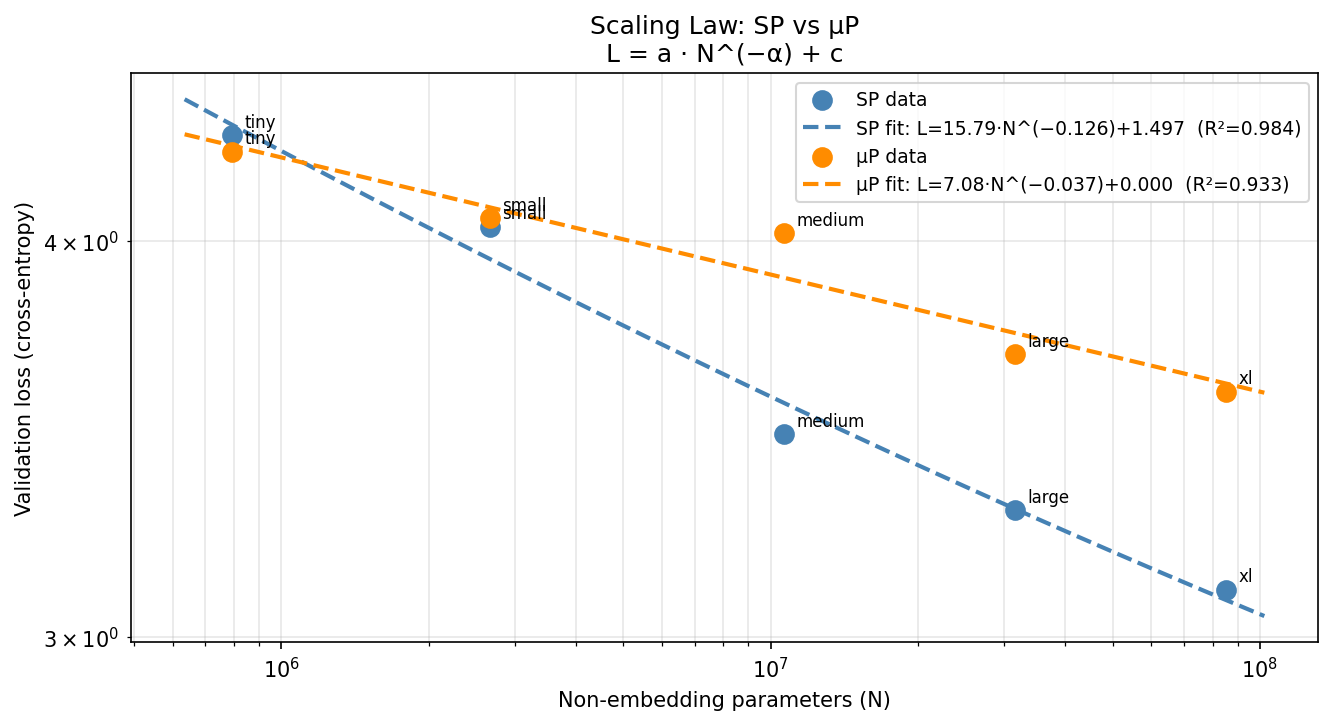

In [67]:
from IPython.display import Image, display
import os

plots = [
    ('SP vs µP Scaling Law (3-way comparison)', 'outputs/plots/scaling_law_comparison.png')
]

for title, path in plots:
    if os.path.exists(path):
        print(f'\n--- {title} ---')
        display(Image(path))
    else:
        print(f'Missing: {path}')


---
## Done!

Phase 3 outputs saved to Drive:

| File | Purpose |
|------|---------|
| `outputs/logs/lr_sweep_mup.json` | µP LR sweep results |
| `outputs/logs/result_mup_<model>.json` | Best val loss per µP model |
| `outputs/logs/scaling_fit_mup.json` | Fitted µP power law parameters |
| `outputs/plots/scaling_law_comparison.png` | SP vs µP scaling curves |
| `outputs/plots/lr_sweep_comparison.png` | SP vs µP LR sweep overlay |

**Next:** Phase 4 — Generation and Evaluation (`04_generation.ipynb`)